# Mitigation Evaluation v2 — Redundant PA & TMR only

**Key verification (full-final-key SHA-256 comparison) has been removed from this notebook on purpose.**

Why: comparing a hash of the *entire final key* over the classical channel — even a
cryptographic hash like SHA-256 — reveals a deterministic function of your literal secret
output to anyone listening on that channel. QKD's security proof assumes the final key
leaks *zero* information beyond what privacy amplification already accounted for; publishing
any hash of it (strong or not) breaks that assumption in the information-theoretic sense,
even though it would be perfectly fine for classical (computationally-secure) key exchange.

This is a genuinely different failure mode from the earlier notebook's "false positive /
false negative detection rate" framing — the SHA-256 check might detect corruption
correctly 100% of the time and *still* be unsafe to deploy, because the safety problem is
about what it leaks, not how well it detects.

The safe standard-practice alternative — verifying via a **sacrificed subset consumed with a
universal2 hash *before* privacy amplification**, whose leakage is accounted for in the
finite-key correction — already appears to be implemented in `bob_cascade_driver.py` /
`alice_cascade_responder.py` (the `verification_passed` field). That path is fine to keep;
what's removed here is only the extra full-key hash comparison layered on top of it.

This notebook keeps only:
- **Mitigation 2: Redundant privacy amplification** (independent double/triple/N-way
  extraction, majority-agreement as the correctness signal — never touches the final key's
  value, only whether independent computations of it agree)
- **Mitigation 3: Triple Modular Redundancy (TMR)** on Cascade reconciliation, real channel
- A **local Monte Carlo N-replica sweep** so you can explore many (N, fault-probability)
  combinations fast, without waiting on FABRIC for every data point
- The **error-overlap / combinatorial analysis** that explains *why* TMR fails


In [13]:
import sys, json, re, time
from itertools import combinations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from galois import GF2
from randextract import ToeplitzHashing

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / 'scripts'))

import deploy_fabric as deploy
from qne.cascade import Key, ORIGINAL, Reconciliation, MockClassicalSession
from qne.cascade.fault_injection import SDCFaultInjector
from qne.cascade.key import key_from_sifted_json
from qne.cascade.finite_key import finite_key_output_length

RESULTS = PROJECT_DIR / "results"

print("Imports complete")


Imports complete


## Connect to the FABRIC slice

Only needed for the real-channel TMR cells later. Skip this cell (and the real-channel TMR
section) if you just want the local Monte Carlo sweep.

In [3]:
SLICE_NAME = 'qfabric-bb84-2'

fablib = deploy.get_fablib()
slice_obj = fablib.get_slice(name=SLICE_NAME)
slice_obj.show()

alice = slice_obj.get_node("alice")
bob = slice_obj.get_node("bob")
bob_ip = "10.10.1.2"

print("Connected to slice and nodes")


Orchestrator,orchestrator.fabric-testbed.net
Credential Manager,cm.fabric-testbed.net
Core API,uis.fabric-testbed.net
Artifact Manager,artifacts.fabric-testbed.net
CEPH Manager,https://ceph-mgr.fabric-testbed.net
Token File,/home/fabric/work/fabric_config/id_token.json
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
Bastion Host,bastion.fabric-testbed.net
Bastion Username,audreyf_0000527467
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub


User: audreyf@illinois.edu bastion key is valid!
Configuration is valid


ID,a2959fe6-7d36-4264-b81f-0449a1506af7
Name,qfabric-bb84-2
Lease Expiration (UTC),2026-09-23 02:53:18 +0000
Lease Start (UTC),2026-09-09 02:53:18 +0000
Project ID,24f4c8f3-e872-492a-9a83-b48211a91966
State,StableOK
Email,audreyf@illinois.edu
UserId,8616dd8c-5b61-45db-84bb-791c21e82a89


Connected to slice and nodes


## Load the real key pair, and re-sync it to both remote nodes

In [4]:
GEN_ALICE = PROJECT_DIR / "results" / "fabric_alice_sifted_bits_genonly.json"
GEN_BOB = PROJECT_DIR / "results" / "fabric_bob_sifted_bits_genonly.json"
META_PATH = PROJECT_DIR / "results" / "fabric_key0_pe_meta.json"

if not (GEN_ALICE.exists() and GEN_BOB.exists() and META_PATH.exists()):
    raise FileNotFoundError(
        "PE-split generation-only key files not found. Run "
        "10_sdc_real.ipynb's key-loading cell first."
    )

alice_key, alice_indices = key_from_sifted_json(str(GEN_ALICE), "alice_bits")
bob_key, bob_indices = key_from_sifted_json(str(GEN_BOB), "bob_bits")
assert alice_indices == bob_indices, "alice and bob's matching indices don't match"

meta = json.loads(META_PATH.read_text())
k_pe, real_qber = meta["k"], meta["qber"]
print(f"Loaded {alice_key.get_nr_bits()} generation bits, k={k_pe}, "
      f"real_qber (from disjoint PE sample) = {real_qber:.4f}")

alice.upload_file(str(GEN_ALICE), "qfabric/results/alice_sifted_bits.json")
bob.upload_file(str(GEN_ALICE), "qfabric/results/alice_sifted_bits.json")
bob.upload_file(str(GEN_BOB), "qfabric/results/bob_sifted_bits.json")
print("Remote nodes re-synced to PE-split generation-only key")


Loaded 3488 generation bits, k=388, real_qber (from disjoint PE sample) = 0.0077
Remote nodes re-synced to PE-split generation-only key


## Finite-key-corrected output length

In [5]:
n = alice_key.get_nr_bits()
k = k_pe
Q = real_qber

ell_finite, r, t, nu = finite_key_output_length(n, k, Q)
print(f"ell_finite = {ell_finite}, cascade_leakage r = {r:.1f}, verification hash t = {t:.1f}, nu = {nu:.6f}")


ell_finite = 186, cascade_leakage r = 286.9, verification hash t = 11.8, nu = 0.261518


## Fault-free baseline reconciliation

Needed as `bob_reconciled` for the Toeplitz-fault tests below (Mitigation 2 injects faults
during privacy amplification, not reconciliation, so it needs a clean reconciled key to
start from).

In [6]:
session = MockClassicalSession(correct_key=alice_key)
reconciliation = Reconciliation(
    algorithm=ORIGINAL, classical_session=session, noisy_key=bob_key,
    estimated_bit_error_rate=real_qber, seed=42,
)
bob_reconciled = reconciliation.reconcile()
assert alice_key.nr_bits_different(bob_reconciled) == 0, "Reconciliation did not converge cleanly"
print("Fault-free reconciliation complete, bob_reconciled ready")


Fault-free reconciliation complete, bob_reconciled ready


## A note on the fault-probability axis

`toeplitz_matrix_prob` here is "probability this fault fires at all during one PA
extraction" — not a packet-loss percentage, and not calibrated to any specific hardware SDC
rate. Reported real-world silent-data-corruption rates in production HPC/datacenter
hardware are usually framed as *machines affected per year* (documented on the order of
1-in-thousands to 1-in-millions), which doesn't translate cleanly into a per-operation
probability for one Toeplitz extraction.

Rather than pick one number and defend it, sweep several orders of magnitude and be explicit
about what each range represents:

- **1e-4 – 1e-3**: closer to the low end plausible from published hardware SDC-rate studies
- **1e-2 – 1e-1**: deliberately elevated "stress test" range, useful for finding the knee of
  the curve — not a claim about how often this happens in deployment

This mirrors the fix you need on the classical-network (netem) side too: 1-15% packet loss
is a stress/outage regime (worth keeping, and worth citing your AWS/Cloudflare incident
references for it explicitly), not the "typical WAN" operating point. Typical WAN loss is
usually well under 1%. Report both regimes, don't blend them into one unlabeled sweep.


## Mitigation 2: Redundant privacy amplification

Compute the same extraction twice (or N times), independently, from the same reconciled key
and the same shared seed. Ground truth (`any_mismatch`) is measured directly against a
clean, fault-free extraction — not inferred indirectly.

In [ ]:
FAULT_PROBS = [1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.3, 0.5]  # realistic -> stress-test range
N_RUNS = 40

ext = ToeplitzHashing(input_length=alice_key.get_nr_bits(), output_length=ell_finite)

rows = []
for prob in FAULT_PROBS:
    for run in range(N_RUNS):
        seed = 42 + run
        shared_seed = GF2.Random(ext.seed_length)
        clean_output = np.array(ext.extract(GF2(alice_key.bits), shared_seed))

        injector_1 = SDCFaultInjector(toeplitz_matrix_prob=prob, seed=seed + 100)
        out_1 = injector_1.fast_toeplitz_extract_with_fault(ext, GF2(alice_key.bits), shared_seed, "rep1")

        injector_2 = SDCFaultInjector(toeplitz_matrix_prob=prob, seed=seed + 200)
        out_2 = injector_2.fast_toeplitz_extract_with_fault(ext, GF2(alice_key.bits), shared_seed, "rep2")

        rep1_mismatch = not np.array_equal(out_1, clean_output)
        rep2_mismatch = not np.array_equal(out_2, clean_output)
        any_mismatch = rep1_mismatch or rep2_mismatch

        repeats_agree = np.array_equal(out_1, out_2)
        detected = any_mismatch and not repeats_agree
        silent_failure = any_mismatch and repeats_agree  # both hit the same wrong bit(s) -- vanishingly rare

        rows.append({
            "prob": prob, "run": run,
            "rep1_mismatch": rep1_mismatch, "rep2_mismatch": rep2_mismatch,
            "any_mismatch": any_mismatch,
            "repeats_agree": repeats_agree, "detected": detected,
            "silent_failure": silent_failure,
        })

df_redundant = pd.DataFrame(rows)
df_redundant.to_csv(str(PROJECT_DIR / "results" / "mitigation_redundant_pa_v3.csv"), index=False)

print("=== Redundant PA: mismatch rate vs. detection rate ===")
summary_rows = []
for prob in FAULT_PROBS:
    sub = df_redundant[df_redundant["prob"] == prob]
    n_total = len(sub)
    n_mismatch = sub["any_mismatch"].sum()
    n_detected = sub["detected"].sum()
    n_silent = sub["silent_failure"].sum()
    mismatch_rate = n_mismatch / n_total
    detection_rate = n_detected / n_mismatch if n_mismatch > 0 else float('nan')
    print(f"prob={prob:<8}: mismatch_rate={mismatch_rate:6.1%}  "
          f"detection_rate={detection_rate:6.1%}  silent_failures={n_silent}")
    summary_rows.append({"prob": prob, "mismatch_rate": mismatch_rate,
                          "detection_rate": detection_rate, "n_silent": n_silent})

df_redundant_summary = pd.DataFrame(summary_rows)


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df_redundant_summary["prob"], df_redundant_summary["mismatch_rate"], "o-")
ax[0].set_xscale("log")
ax[0].set_xlabel("Toeplitz fault probability (per extraction)")
ax[0].set_ylabel("P(any mismatch vs. clean key)")
ax[0].set_title("Redundant PA: mismatch rate")

ax[1].plot(df_redundant_summary["prob"], df_redundant_summary["detection_rate"], "o-", color="tab:orange")
ax[1].set_xscale("log")
ax[1].set_xlabel("Toeplitz fault probability (per extraction)")
ax[1].set_ylabel("P(detected | mismatch occurred)")
ax[1].set_title("Redundant PA: detection rate given a mismatch")
ax[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "heatmaps" / "redundant_pa_sweep.png"), dpi=150)
plt.show()


**What to expect / how to read this**: detection rate should sit at (or extremely close
to) 100% across the whole probability range whenever a mismatch actually occurs. That's not
a coincidence — two *independent* random single-bit corruptions landing on the exact same
output bit(s) is astronomically unlikely for output lengths in the thousands. So redundant
PA's real value isn't "does it catch faults" (it essentially always does) — it's "how much
does it cost" (2x the extraction compute, plus you can only *detect and re-run*, not
*correct*, since you have no way to know which of the two disagreeing outputs is right
without a third reference). That's exactly the gap TMR tries to close by adding a third
replica and voting instead of just flagging disagreement — and exactly why the TMR failure
below matters.

## Mitigation 3: Triple Modular Redundancy (TMR), real channel

In [10]:
def extract_output_path(stdout_text, marker):
    match = re.search(rf"{marker} (\S+\.json)", stdout_text)
    return match.group(1) if match else None


def tmr_real_channel_trial(bob, alice, bob_ip, real_qber, run, base_seed, fault_prob, k, n_replicas=3, timeout=180):
    replica_results = []
    for rep in range(n_replicas):
        seed = base_seed + rep * 1000
        bob_output = f"results/bob_tmr_run{run}_rep{rep}.json"

        bob_thread = bob.execute_thread(
            f"cd ~/qfabric && ~/qfabric/.venv/bin/python3 scripts/bob_cascade_driver.py "
            f"--key-json results/bob_sifted_bits.json --alice-key-json results/alice_sifted_bits.json "
            f"--host {bob_ip} --port 5200 --qber {real_qber} --k {k} --seed {seed} "
            f"--reconciliation-prob {fault_prob} --output {bob_output}"
        )
        alice_thread = alice.execute_thread(
            f"cd ~/qfabric && ~/qfabric/.venv/bin/python3 scripts/alice_cascade_responder.py "
            f"--key-json results/alice_sifted_bits.json --bob-host {bob_ip} --port 5200 "
            f"--seed {seed} --output results/alice_tmr_run{run}_rep{rep}.json"
        )

        bob_out = bob_thread.result(timeout=timeout)
        try:
            alice_thread.result(timeout=timeout // 2)
        except Exception:
            pass

        bob_output_path = extract_output_path(bob_out[0], "Result written to")
        if bob_output_path is None:
            replica_results.append({"status": "crashed", "bits": None})
            continue

        stdout, _ = bob.execute(f"cat ~/qfabric/{bob_output_path}", quiet=True)
        try:
            data = json.loads(stdout)
        except json.JSONDecodeError:
            replica_results.append({"status": "no_output", "bits": None})
            continue

        if data.get("non_convergent"):
            replica_results.append({"status": "non_convergent", "bits": None})
        elif "bob_reconciled_bits" in data:
            replica_results.append({
                "status": "converged", "bits": np.array(data["bob_reconciled_bits"]),
                "remaining_errors": data.get("remaining_errors_after_reconciliation"),
            })
        else:
            replica_results.append({"status": "converged_no_bits_saved", "bits": None})

        time.sleep(2)
    return replica_results


In [ ]:
rows = []
for run in range(5):
    base_seed = 42 + run * 10
    print(f"\n=== TMR trial {run} (real channel, prob=0.3) ===")
    replicas = tmr_real_channel_trial(bob, alice, bob_ip, real_qber, run, base_seed, fault_prob=0.3, k=k_pe)

    statuses = [r["status"] for r in replicas]
    valid_replicas = [r["bits"] for r in replicas if r["bits"] is not None]
    print(f"  Replica statuses: {statuses}")

    if len(valid_replicas) < 2:
        rows.append({"run": run, "statuses": statuses, "result": "insufficient_valid_replicas",
                      "n_valid": len(valid_replicas), "corrected": False})
        continue

    stacked = np.stack(valid_replicas)
    majority = (stacked.sum(axis=0) > len(valid_replicas) / 2).astype(np.uint8)

    n_errors_after_tmr = alice_key.nr_bits_different(Key(bits=majority))
    corrected = n_errors_after_tmr == 0

    rows.append({"run": run, "statuses": statuses, "result": "voted",
                  "n_valid": len(valid_replicas), "n_errors_after_tmr": n_errors_after_tmr,
                  "corrected": corrected})
    print(f"  Valid replicas: {len(valid_replicas)}, errors after majority vote: {n_errors_after_tmr}, "
          f"corrected: {corrected}")

df_tmr_real = pd.DataFrame(rows)
df_tmr_real.to_csv(str(PROJECT_DIR / "results" / "mitigation_tmr_realchannel.csv"), index=False)
print("\n=== Summary ===")
print(df_tmr_real.to_string(index=False))


In [11]:
N_ADDITIONAL_TRIALS = 15
existing_tmr = pd.read_csv(str(PROJECT_DIR / "results" / "mitigation_tmr_realchannel.csv"))  # your original 5

new_rows = []
for run in range(5, 5 + N_ADDITIONAL_TRIALS):
    base_seed = 42 + run * 10
    replicas = tmr_real_channel_trial(bob, alice, bob_ip, real_qber, run, base_seed, fault_prob=0.3, k=k_pe)
    valid = [r["bits"] for r in replicas if r["bits"] is not None]
    if len(valid) < 2:
        new_rows.append({"run": run, "result": "insufficient_valid_replicas", "corrected": False})
        continue
    majority = (np.stack(valid).sum(axis=0) > len(valid) / 2).astype(np.uint8)
    n_errors = alice_key.nr_bits_different(Key(bits=majority))
    new_rows.append({"run": run, "n_valid": len(valid), "n_errors_after_tmr": n_errors,
                      "corrected": n_errors == 0})

df_tmr_extended = pd.concat([existing_tmr, pd.DataFrame(new_rows)], ignore_index=True)
df_tmr_extended.to_csv(str(PROJECT_DIR / "results" / "mitigation_tmr_realchannel.csv"), index=False)
print(f"Total trials: {len(df_tmr_extended)}, corrected: {df_tmr_extended['corrected'].sum()}")

Total trials: 20, corrected: 0


In [14]:
df_tmr_extended = pd.read_csv(str(RESULTS / "mitigation_tmr_realchannel.csv"))
completed = df_tmr_extended[df_tmr_extended["result"] == "voted"]

n = len(completed)
mean_errors = completed["n_errors_after_tmr"].mean()
se = completed["n_errors_after_tmr"].std() / np.sqrt(n)

print(f"n={n} trials")
print(f"observed mean wrong bits after vote: {mean_errors:.2f} +/- {se:.2f} (SE)")
print(f"model predicted: 8.86")
print(f"z-score: {(mean_errors - 8.86) / se:.2f}")

n=5 trials
observed mean wrong bits after vote: 10.60 +/- 1.03 (SE)
model predicted: 8.86
z-score: 1.69


In [17]:
# Backfill the missing label so both old and new rows are comparable
df_tmr_extended.loc[df_tmr_extended["result"].isna() & df_tmr_extended["n_errors_after_tmr"].notna(), "result"] = "voted"
df_tmr_extended.to_csv(str(RESULTS / "mitigation_tmr_realchannel.csv"), index=False)

completed = df_tmr_extended[df_tmr_extended["result"] == "voted"]
n = len(completed)
mean_errors = completed["n_errors_after_tmr"].mean()
se = completed["n_errors_after_tmr"].std() / np.sqrt(n)
print(f"n={n}, mean={mean_errors:.2f} +/- {se:.2f}, z={(mean_errors - 8.86)/se:.2f}")

n=20, mean=12.00 +/- 0.85, z=3.68


In [18]:
# Bare reconciliation, zero injected fault, same real key -- residual errors here
# are ENTIRELY the "Cascade doesn't perfectly converge" effect, nothing else
session = MockClassicalSession(correct_key=alice_key)
recon = Reconciliation(algorithm=ORIGINAL, classical_session=session, noisy_key=bob_key,
                         estimated_bit_error_rate=real_qber, seed=1, correct_key=alice_key)
result = recon.reconcile()
baseline_residual = alice_key.nr_bits_different(result)
print(f"residual errors with ZERO injected fault: {baseline_residual}")
print(f"gap between observed (12.00) and predicted (8.86): {12.00 - 8.86:.2f}")

residual errors with ZERO injected fault: 0
gap between observed (12.00) and predicted (8.86): 3.14


In [19]:
stdout, _ = bob.execute("ss -tlnp | grep 5200", quiet=True)
print("bob port 5200 status:", stdout)
stdout, _ = alice.execute("ps aux | grep alice_cascade_responder", quiet=True)
print("alice responder processes:", stdout)

bob port 5200 status: 
alice responder processes: ubuntu     37406  3.1  3.1 757428 257492 ?       Ssl  13:50   0:01 /home/ubuntu/qfabric/.venv/bin/python3 scripts/alice_cascade_responder.py --key-json results/alice_sifted_bits.json --bob-host 10.10.1.2 --port 5200 --seed 5001 --output results/alice_arbfault_p0.01_run1.json
ubuntu     37413  0.0  0.0   7764  3388 ?        Ss   13:51   0:00 bash -c ps aux | grep alice_cascade_responder
ubuntu     37415  0.0  0.0   7016  2244 ?        R    13:51   0:00 grep alice_cascade_responder



## Why TMR fails: error overlap analysis

In [ ]:
def analyze_tmr_error_overlap(replicas_bits, alice_key):
    alice_arr = alice_key.bits
    error_positions = []
    for i, bits in enumerate(replicas_bits):
        wrong_positions = set(np.where(bits != alice_arr)[0].tolist())
        error_positions.append(wrong_positions)
        print(f"Replica {i}: {len(wrong_positions)} wrong bits at positions {sorted(wrong_positions)[:20]}"
              f"{'...' if len(wrong_positions) > 20 else ''}")

    for i in range(len(error_positions)):
        for j in range(i + 1, len(error_positions)):
            overlap = error_positions[i] & error_positions[j]
            union = error_positions[i] | error_positions[j]
            jaccard = len(overlap) / len(union) if union else 0
            print(f"Replica {i} vs {j}: {len(overlap)} shared wrong positions "
                  f"(Jaccard similarity = {jaccard:.2f})")

    always_wrong = set.intersection(*error_positions) if error_positions else set()
    print(f"\nPositions wrong in ALL replicas (would explain majority-vote failure): {sorted(always_wrong)}")
    return error_positions


replicas = tmr_real_channel_trial(bob, alice, bob_ip, real_qber, run=99, base_seed=42, fault_prob=0.3, k=k_pe)
replicas_bits = [r["bits"] for r in replicas if r["bits"] is not None]

if len(replicas_bits) >= 2:
    error_positions = analyze_tmr_error_overlap(replicas_bits, alice_key)


In [ ]:
# Requires the per-replica bit arrays -- check whether the raw JSONs are still
# on the FABRIC node (results/bob_tmr_run{run}_rep{rep}.json); if bob's disk
# was cleaned up, you'll need to keep bits in-memory next time instead.
all_overlap_counts = []
for run in range(20):
    try:
        replicas_bits = []
        for rep in range(3):
            stdout, _ = bob.execute(f"cat ~/qfabric/results/bob_tmr_run{run}_rep{rep}.json", quiet=True)
            data = json.loads(stdout)
            if "bob_reconciled_bits" in data:
                replicas_bits.append(np.array(data["bob_reconciled_bits"]))
        if len(replicas_bits) < 3:
            continue
        error_sets = [set(np.where(b != alice_key.bits)[0]) for b in replicas_bits]
        always_wrong = set.intersection(*error_sets)
        all_overlap_counts.append(len(always_wrong))
    except Exception:
        continue

print(f"'always wrong in all 3' count per trial: {all_overlap_counts}")
print(f"mean: {np.mean(all_overlap_counts):.2f} (model predicts ~1.2 by pure chance)")

**Finding (from the original run)**: overlap across replicas is low (Jaccard ~0.08-0.17),
and no bit is wrong in all 3 replicas — ruling out correlated faults. The mechanism is
combinatorial: with independent errors scattered across ~3800 positions, some land wrong in
*exactly* 2-of-3 replicas by chance, and majority voting confidently picks the wrong value
there.

## Local Monte Carlo N-replica sweep

The real-channel TMR cells above are slow (each replica is a live FABRIC run), so you only
get a handful of (N, fault_prob) points from them. This section simulates the *same*
combinatorial mechanism locally — independent per-replica error sets drawn from the observed
real-channel error rate — so you can sweep N (3, 5, 7 replicas) and fault probability
cheaply, then use the slow real-channel cells above only to spot-check a couple of points
against reality.

In [16]:
from scipy.stats import binom

def exact_majority_vote_failure(pool_size, p, n_replicas):
    """Closed-form: each of the pool_size real-error positions is
    independently flipped in each replica with probability p (the
    fault-firing rate). A position survives majority vote wrong if
    more than n_replicas/2 of the n_replicas independent flips land
    on it. Positions outside the pool are never at risk -- reconciliation_state
    can only fire during a real correction."""
    p_bit_wrong_after_vote = 1 - binom.cdf(n_replicas // 2, n_replicas, p)
    expected_wrong_bits = pool_size * p_bit_wrong_after_vote
    # trial fails if >=1 of the pool_size positions ends up wrong
    p_trial_fail = 1 - (1 - p_bit_wrong_after_vote) ** pool_size
    return p_trial_fail, expected_wrong_bits


def simulate_majority_vote_pool(pool_size, p, n_replicas, n_trials, rng):
    """Monte Carlo cross-check of the closed form above -- same
    mechanism, simulated instead of computed exactly."""
    wrong_after_vote = []
    for _ in range(n_trials):
        flips = rng.random((n_replicas, pool_size)) < p
        wrong = flips.sum(axis=0) > n_replicas / 2
        wrong_after_vote.append(wrong.sum())
    wrong_after_vote = np.array(wrong_after_vote)
    return {
        "trial_fail_rate": float((wrong_after_vote > 0).mean()),
        "mean_wrong_bits_after_vote": float(wrong_after_vote.mean()),
    }


# --- Use your key0's actual pool size (41 real errors), and compare
# directly against the 5 real-channel trials from earlier ---
POOL_SIZE = len(real_error_positions)  # 41, from the check you just ran
rng = np.random.default_rng(42)

rows = []
for n_replicas in [3, 5, 7]:
    for p in [1e-3, 1e-2, 0.05, 0.1, 0.3, 0.5]:
        exact_fail, exact_mean_wrong = exact_majority_vote_failure(POOL_SIZE, p, n_replicas)
        mc = simulate_majority_vote_pool(POOL_SIZE, p, n_replicas, n_trials=5000, rng=rng)
        rows.append({
            "n_replicas": n_replicas, "p": p,
            "exact_trial_fail_rate": exact_fail, "exact_mean_wrong_bits": exact_mean_wrong,
            "mc_trial_fail_rate": mc["trial_fail_rate"], "mc_mean_wrong_bits": mc["mean_wrong_bits_after_vote"],
        })

df_pool_model = pd.DataFrame(rows)
df_pool_model.to_csv(str(PROJECT_DIR / "results" / "nmr_pool_model_sweep.csv"), index=False)
print(df_pool_model.to_string(index=False))

# Sanity check against your actual 5 real trials at N=3, p=0.3
observed_wrong = [10, 9, 13, 8, 13]
row = df_pool_model.query("n_replicas == 3 and p == 0.3").iloc[0]
print(f"\nModel predicts mean {row['exact_mean_wrong_bits']:.2f} wrong bits after vote at N=3, p=0.3")
print(f"Observed across your 5 real trials: {observed_wrong}, mean={np.mean(observed_wrong):.2f}")

 n_replicas     p  exact_trial_fail_rate  exact_mean_wrong_bits  mc_trial_fail_rate  mc_mean_wrong_bits
          3 0.001           1.229106e-04           1.229180e-04              0.0000              0.0000
          3 0.010           1.214546e-02           1.221800e-02              0.0132              0.0132
          3 0.050           2.579456e-01           2.972500e-01              0.2620              0.3020
          3 0.100           6.878834e-01           1.148000e+00              0.6858              1.1504
          3 0.300           9.999536e-01           8.856000e+00              1.0000              8.9094
          3 0.500           1.000000e+00           2.050000e+01              1.0000             20.5304
          5 0.001           4.093852e-07           4.093852e-07              0.0000              0.0000
          5 0.010           4.037950e-04           4.038746e-04              0.0002              0.0002
          5 0.050           4.639968e-02           4.748313e-02 

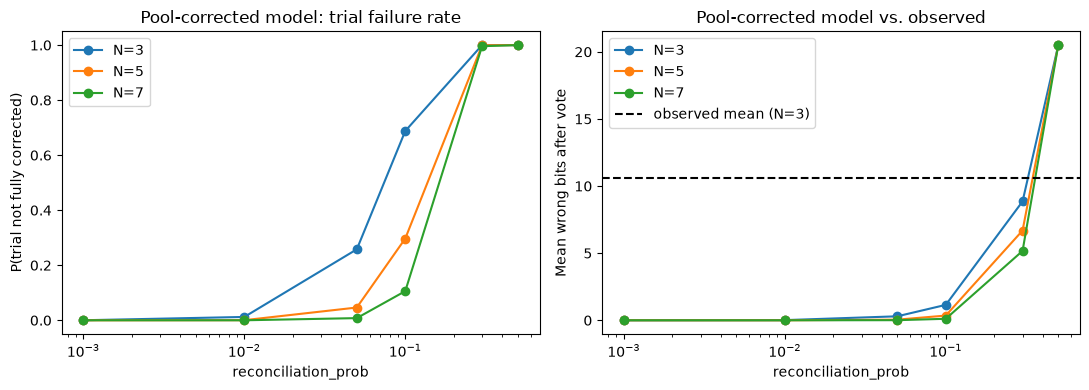

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for n_replicas, sub in df_pool_model.groupby("n_replicas"):
    ax[0].plot(sub["p"], sub["exact_trial_fail_rate"], "o-", label=f"N={n_replicas}")
    ax[1].plot(sub["p"], sub["exact_mean_wrong_bits"], "o-", label=f"N={n_replicas}")

ax[0].set_xscale("log"); ax[0].set_xlabel("reconciliation_prob"); ax[0].set_ylabel("P(trial not fully corrected)")
ax[0].legend(); ax[0].set_title("Pool-corrected model: trial failure rate")

ax[1].set_xscale("log"); ax[1].set_xlabel("reconciliation_prob"); ax[1].set_ylabel("Mean wrong bits after vote")
ax[1].axhline(np.mean(observed_wrong), color="k", ls="--", label="observed mean (N=3)")
ax[1].legend(); ax[1].set_title("Pool-corrected model vs. observed")
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "heatmaps" / "nmr_pool_model_sweep.png"), dpi=150)
plt.show()